In [9]:


import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import logit

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts

# Time-series
from prophet import Prophet          # uncomment if installed
from pmdarima import auto_arima      # uncomment if installed

#Geo (optional — comment out if geopandas not installed)
import geopandas as gpd
import folium

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})


In [12]:
import pandas as pd
df = pd.read_csv("df_clean.csv")

# ════════════════════════════════════════════════════════════════════════════════
# CELL 6.1 — Contact Tracing Analysis (using actual column names)
# ════════════════════════════════════════════════════════════════════════════════


SECTION 6.1 — CONTACT TRACING ANALYSIS

 Contacts per case:
   Total contacts listed: 26,819
   Average contacts per case: 3.1


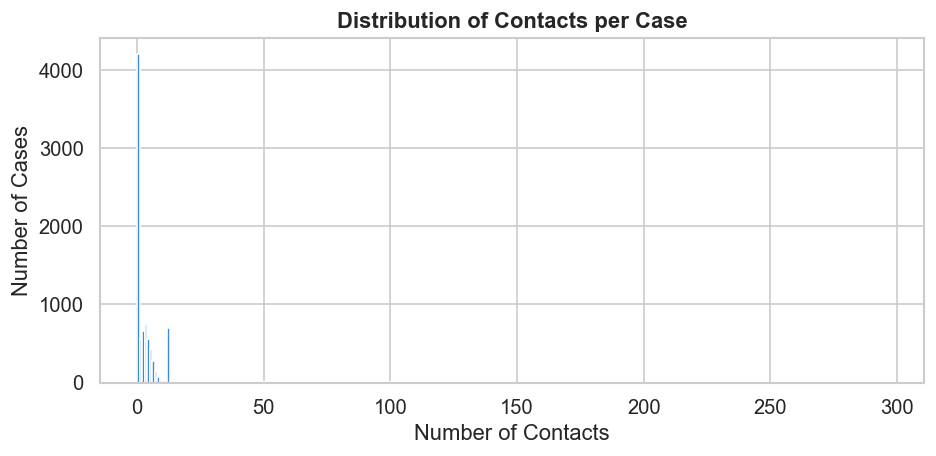


 Contacts screened for symptoms: 24,127

 Contacts Screened by District (Top 15):


,District,Contacts Screened
29,Rwamagana District,4947
7,Huye District,2717
24,Rubavu District,2266
11,Kicukiro District,1530
21,Nyanza District,1341
13,Muhanga District,1224
14,Musanze District,962
18,Nyagatare District,902
22,Nyarugenge District,795
3,Gasabo District,737



 TB‑positive contacts identified: 382
   (Denominator for contacts tested is not available; positivity rate not computed.)

Note: No column for 'contacts traced' was found. Tracing is assumed from screened contacts.


In [7]:
# Define the color palette (or use existing)
BLUE = '#378ADD'   # if not already defined

print("SECTION 6.1 — CONTACT TRACING ANALYSIS")

# ---- 1. Number of contacts per case ----
if 'contacts_total' in df.columns:
    contacts_series = df['contacts_total'].dropna()
    if pd.api.types.is_numeric_dtype(contacts_series):
        total_contacts = contacts_series.sum()
        avg_contacts = contacts_series.mean()
        print(f"\n Contacts per case:")
        print(f"   Total contacts listed: {total_contacts:,.0f}")
        print(f"   Average contacts per case: {avg_contacts:.1f}")
        # Distribution histogram
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(contacts_series, bins=range(0, int(contacts_series.max())+2),
                edgecolor='white', color=BLUE)
        ax.set_title('Distribution of Contacts per Case', fontweight='bold')
        ax.set_xlabel('Number of Contacts')
        ax.set_ylabel('Number of Cases')
        plt.tight_layout()
        plt.savefig('fig_6_1_contacts_per_case.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print("Column 'contacts_total' exists but is not numeric.")
else:
    print("Column 'contacts_total' not found. Skipping contacts per case.")

# ---- 2. Contacts screened (by district, using age‑split columns) ----
# We'll sum contacts screened from both age groups
if 'contacts_u5_screened' in df.columns and 'contacts_5plus_screened' in df.columns:
    # Create a total screened column
    df['contacts_screened_total'] = df['contacts_u5_screened'].fillna(0) + df['contacts_5plus_screened'].fillna(0)
    total_screened = df['contacts_screened_total'].sum()
    print(f"\n Contacts screened for symptoms: {total_screened:,.0f}")

    # Screened by district (if district column exists)
    if 'district' in df.columns:
        screened_by_district = df.groupby('district')['contacts_screened_total'].sum().reset_index()
        screened_by_district.columns = ['District', 'Contacts Screened']
        screened_by_district = screened_by_district.sort_values('Contacts Screened', ascending=False)
        print("\n Contacts Screened by District (Top 15):")
        display(screened_by_district.head(15))
else:
    print("Columns for contacts screened not found.")

# ---- 3. TB positive among contacts (from screening) ----
if 'contacts_u5_tb_pos' in df.columns and 'contacts_5plus_tb_pos' in df.columns:
    df['contacts_tb_pos_total'] = df['contacts_u5_tb_pos'].fillna(0) + df['contacts_5plus_tb_pos'].fillna(0)
    total_pos = df['contacts_tb_pos_total'].sum()
    print(f"\n TB‑positive contacts identified: {total_pos:,.0f}")
    # Note: positivity rate cannot be calculated because tested denominator is missing.
    print("   (Denominator for contacts tested is not available; positivity rate not computed.)")
else:
    print("Columns for TB‑positive contacts not found.")

# ---- 4. (Optional) Contacts traced - not available in data ----
print("\nNote: No column for 'contacts traced' was found. Tracing is assumed from screened contacts.")

# ════════════════════════════════════════════════════════════════════════════════
# CELL 6.2 — Age‑specific Contact Analysis (under 5 and 5+ years)
# ════════════════════════════════════════════════════════════════════════════════



In [8]:
print("SECTION 6.2 — AGE‑SPECIFIC CONTACT ANALYSIS")

# ── Contact tracing summary for under‑5 and 5+ ───────────────────────────────
contact_summary = []

# Under 5 years
if all(col in df.columns for col in ['contacts_u5_living', 'contacts_u5_screened', 'contacts_u5_tb_pos']):
    living_u5 = df['contacts_u5_living'].sum()
    screened_u5 = df['contacts_u5_screened'].sum()
    tb_pos_u5 = df['contacts_u5_tb_pos'].sum()
    coverage_u5 = (screened_u5 / living_u5 * 100) if living_u5 > 0 else 0

    contact_summary.append({
        'Age Group': '<5 years',
        'Contacts Living': f'{living_u5:,.0f}',
        'Contacts Screened': f'{screened_u5:,.0f}',
        'Screening Coverage (%)': f'{coverage_u5:.1f}',
        'TB Positive Contacts': f'{tb_pos_u5:,.0f}'
    })
else:
    print("Missing columns for under‑5 contact tracing.")

# 5+ years
if all(col in df.columns for col in ['contacts_5plus_living', 'contacts_5plus_screened', 'contacts_5plus_tb_pos']):
    living_5p = df['contacts_5plus_living'].sum()
    screened_5p = df['contacts_5plus_screened'].sum()
    tb_pos_5p = df['contacts_5plus_tb_pos'].sum()
    coverage_5p = (screened_5p / living_5p * 100) if living_5p > 0 else 0

    contact_summary.append({
        'Age Group': '≥5 years',
        'Contacts Living': f'{living_5p:,.0f}',
        'Contacts Screened': f'{screened_5p:,.0f}',
        'Screening Coverage (%)': f'{coverage_5p:.1f}',
        'TB Positive Contacts': f'{tb_pos_5p:,.0f}'
    })

if contact_summary:
    print("\n▶ Contact Tracing Summary by Age Group:")
    display(pd.DataFrame(contact_summary))

# ── TST for contacts ≥5 years (if available) ───────────────────────────────
if 'tst_done_5plus' in df.columns and 'tst_positive_5plus' in df.columns:
    tst_done = df['tst_done_5plus'].sum()
    tst_pos = df['tst_positive_5plus'].sum()
    tst_pos_rate = (tst_pos / tst_done * 100) if tst_done > 0 else 0
    print(f"\n▶ TST (≥5 years):")
    print(f"   TST done: {tst_done:,.0f}")
    print(f"   TST positive: {tst_pos:,.0f} ({tst_pos_rate:.1f}%)")
else:
    print("\nTST columns for ≥5 years not found.")

# ── TPT outcomes for contacts ───────────────────────────────────────────────
print("\n▶ TPT Initiation and Outcomes Among Contacts:")

tpt_data = []

# Under 5 years – split into <2 years and 2–5 years
u2_started = df['tpt_started_u2'].sum() if 'tpt_started_u2' in df.columns else 0
u2_5_started = df['tpt_started_2to5'].sum() if 'tpt_started_2to5' in df.columns else 0
u5_started = u2_started + u2_5_started

# Outcomes for under‑5 (combined columns: completed, ltfu, died, se, not_eval, active_tb)
tpt_completed_u5 = df['tpt_completed_u5'].sum() if 'tpt_completed_u5' in df.columns else 'N/A'
tpt_ltfu_u5 = df['tpt_ltfu_u5'].sum() if 'tpt_ltfu_u5' in df.columns else 'N/A'
tpt_died_u5 = df['tpt_died_u5'].sum() if 'tpt_died_u5' in df.columns else 'N/A'
tpt_se_u5 = df['tpt_se_u5'].sum() if 'tpt_se_u5' in df.columns else 'N/A'
tpt_not_eval_u5 = df['tpt_not_eval_u5'].sum() if 'tpt_not_eval_u5' in df.columns else 'N/A'
tpt_active_u5 = df['tpt_active_tb_u5'].sum() if 'tpt_active_tb_u5' in df.columns else 'N/A'

tpt_data.append({
    'Age Group': '<5 years',
    'Started TPT': f'{u5_started:,.0f}',
    'Completed TPT': tpt_completed_u5,
    'LTFU on TPT': tpt_ltfu_u5,
    'Died on TPT': tpt_died_u5,
    'Developed active TB': tpt_active_u5,
    'Discontinued (side effects)': tpt_se_u5,
    'Not evaluated': tpt_not_eval_u5
})

# ≥5 years – columns for TPT outcomes
if 'tpt_started_5plus' in df.columns:
    tpt_started_5p = df['tpt_started_5plus'].sum()
    tpt_completed_5p = df['tpt_completed_5plus'].sum() if 'tpt_completed_5plus' in df.columns else 'N/A'
    tpt_ltfu_5p = df['tpt_ltfu_5plus'].sum() if 'tpt_ltfu_5plus' in df.columns else 'N/A'
    tpt_died_5p = df['tpt_died_5plus'].sum() if 'tpt_died_5plus' in df.columns else 'N/A'
    tpt_se_5p = df['tpt_se_5plus'].sum() if 'tpt_se_5plus' in df.columns else 'N/A'
    tpt_not_eval_5p = df['tpt_not_eval_5plus'].sum() if 'tpt_not_eval_5plus' in df.columns else 'N/A'
    tpt_active_5p = df['tpt_active_tb_5plus'].sum() if 'tpt_active_tb_5plus' in df.columns else 'N/A'

    tpt_data.append({
        'Age Group': '≥5 years',
        'Started TPT': f'{tpt_started_5p:,.0f}',
        'Completed TPT': tpt_completed_5p,
        'LTFU on TPT': tpt_ltfu_5p,
        'Died on TPT': tpt_died_5p,
        'Developed active TB': tpt_active_5p,
        'Discontinued (side effects)': tpt_se_5p,
        'Not evaluated': tpt_not_eval_5p
    })

if tpt_data:
    display(pd.DataFrame(tpt_data))
else:
    print("No TPT columns found.")

SECTION 6.2 — AGE‑SPECIFIC CONTACT ANALYSIS

▶ Contact Tracing Summary by Age Group:


,Age Group,Contacts Living,Contacts Screened,Screening Coverage (%),TB Positive Contacts
0,<5 years,"1,394","1,362",97.7,55
1,≥5 years,"22,922","22,765",99.3,327



▶ TST (≥5 years):
   TST done: 9,549
   TST positive: 1,607 (16.8%)

▶ TPT Initiation and Outcomes Among Contacts:


,Age Group,Started TPT,Completed TPT,LTFU on TPT,Died on TPT,Developed active TB,Discontinued (side effects),Not evaluated
0,<5 years,"1,301",800,4,1,10,-15,0
1,≥5 years,"1,577",1114,0,0,1,1,0


# ════════════════════════════════════════════════════════════════════════════════
# CELL 6.2 — Age‑specific Contact Analysis (under 5 and 5+ years)
# ════════════════════════════════════════════════════════════════════════════════

In [ ]:

print("SECTION 6.2 — AGE‑SPECIFIC CONTACT ANALYSIS")

# ── Contact tracing summary for under‑5 and 5+ 
contact_summary = []

# Under 5 years
if all(col in df.columns for col in ['contacts_u5_living', 'contacts_u5_screened', 'contacts_u5_tb_pos']):
    living_u5 = df['contacts_u5_living'].sum()
    screened_u5 = df['contacts_u5_screened'].sum()
    tb_pos_u5 = df['contacts_u5_tb_pos'].sum()
    coverage_u5 = (screened_u5 / living_u5 * 100) if living_u5 > 0 else 0

    contact_summary.append({
        'Age Group': '<5 years',
        'Contacts Living': f'{living_u5:,.0f}',
        'Contacts Screened': f'{screened_u5:,.0f}',
        'Screening Coverage (%)': f'{coverage_u5:.1f}',
        'TB Positive Contacts': f'{tb_pos_u5:,.0f}'
    })
else:
    print("Missing columns for under‑5 contact tracing.")

# 5+ years
if all(col in df.columns for col in ['contacts_5plus_living', 'contacts_5plus_screened', 'contacts_5plus_tb_pos']):
    living_5p = df['contacts_5plus_living'].sum()
    screened_5p = df['contacts_5plus_screened'].sum()
    tb_pos_5p = df['contacts_5plus_tb_pos'].sum()
    coverage_5p = (screened_5p / living_5p * 100) if living_5p > 0 else 0

    contact_summary.append({
        'Age Group': '≥5 years',
        'Contacts Living': f'{living_5p:,.0f}',
        'Contacts Screened': f'{screened_5p:,.0f}',
        'Screening Coverage (%)': f'{coverage_5p:.1f}',
        'TB Positive Contacts': f'{tb_pos_5p:,.0f}'
    })

if contact_summary:
    print("\n Contact Tracing Summary by Age Group:")
    display(pd.DataFrame(contact_summary))

# ── TST for contacts ≥5 years 
if 'tst_done_5plus' in df.columns and 'tst_positive_5plus' in df.columns:
    tst_done = df['tst_done_5plus'].sum()
    tst_pos = df['tst_positive_5plus'].sum()
    tst_pos_rate = (tst_pos / tst_done * 100) if tst_done > 0 else 0
    print(f"\n TST (≥5 years):")
    print(f"   TST done: {tst_done:,.0f}")
    print(f"   TST positive: {tst_pos:,.0f} ({tst_pos_rate:.1f}%)")
else:
    print("\nTST columns for ≥5 years not found.")

# ── TPT outcomes for contacts 
print("\n TPT Initiation and Outcomes Among Contacts:")

tpt_data = []

# Under 5 years – split into <2 years and 2–5 years
u2_started = df['tpt_started_u2'].sum() if 'tpt_started_u2' in df.columns else 0
u2_5_started = df['tpt_started_2to5'].sum() if 'tpt_started_2to5' in df.columns else 0
u5_started = u2_started + u2_5_started

# Outcomes for under‑5
tpt_completed_u5 = df['tpt_completed_u5'].sum() if 'tpt_completed_u5' in df.columns else 0
tpt_ltfu_u5 = df['tpt_ltfu_u5'].sum() if 'tpt_ltfu_u5' in df.columns else 0
tpt_died_u5 = df['tpt_died_u5'].sum() if 'tpt_died_u5' in df.columns else 0
tpt_se_u5 = df['tpt_se_u5'].sum() if 'tpt_se_u5' in df.columns else 0
tpt_not_eval_u5 = df['tpt_not_eval_u5'].sum() if 'tpt_not_eval_u5' in df.columns else 0
tpt_active_u5 = df['tpt_active_tb_u5'].sum() if 'tpt_active_tb_u5' in df.columns else 0

# Warn if negative values found in side effects
if tpt_se_u5 < 0:
    print("  Warning: Negative value in tpt_se_u5 column – please check source data.")

tpt_data.append({
    'Age Group': '<5 years',
    'Started TPT': f'{u5_started:,.0f}',
    'Completed TPT': f'{tpt_completed_u5:,.0f}',
    'LTFU on TPT': f'{tpt_ltfu_u5:,.0f}',
    'Died on TPT': f'{tpt_died_u5:,.0f}',
    'Developed active TB': f'{tpt_active_u5:,.0f}',
    'Discontinued (side effects)': f'{tpt_se_u5:,.0f}',
    'Not evaluated': f'{tpt_not_eval_u5:,.0f}'
})

# ≥5 years
if 'tpt_started_5plus' in df.columns:
    tpt_started_5p = df['tpt_started_5plus'].sum()
    tpt_completed_5p = df['tpt_completed_5plus'].sum() if 'tpt_completed_5plus' in df.columns else 0
    tpt_ltfu_5p = df['tpt_ltfu_5plus'].sum() if 'tpt_ltfu_5plus' in df.columns else 0
    tpt_died_5p = df['tpt_died_5plus'].sum() if 'tpt_died_5plus' in df.columns else 0
    tpt_se_5p = df['tpt_se_5plus'].sum() if 'tpt_se_5plus' in df.columns else 0
    tpt_not_eval_5p = df['tpt_not_eval_5plus'].sum() if 'tpt_not_eval_5plus' in df.columns else 0
    tpt_active_5p = df['tpt_active_tb_5plus'].sum() if 'tpt_active_tb_5plus' in df.columns else 0

    tpt_data.append({
        'Age Group': '≥5 years',
        'Started TPT': f'{tpt_started_5p:,.0f}',
        'Completed TPT': f'{tpt_completed_5p:,.0f}',
        'LTFU on TPT': f'{tpt_ltfu_5p:,.0f}',
        'Died on TPT': f'{tpt_died_5p:,.0f}',
        'Developed active TB': f'{tpt_active_5p:,.0f}',
        'Discontinued (side effects)': f'{tpt_se_5p:,.0f}',
        'Not evaluated': f'{tpt_not_eval_5p:,.0f}'
    })

if tpt_data:
    display(pd.DataFrame(tpt_data))
else:
    print("No TPT columns found.")

SECTION 6.2 — AGE‑SPECIFIC CONTACT ANALYSIS

 Contact Tracing Summary by Age Group:


,Age Group,Contacts Living,Contacts Screened,Screening Coverage (%),TB Positive Contacts
0,<5 years,"1,394","1,362",97.7,55
1,≥5 years,"22,922","22,765",99.3,327



 TST (≥5 years):
   TST done: 9,549
   TST positive: 1,607 (16.8%)

 TPT Initiation and Outcomes Among Contacts:


,Age Group,Started TPT,Completed TPT,LTFU on TPT,Died on TPT,Developed active TB,Discontinued (side effects),Not evaluated
0,<5 years,"1,301",800,4,1,10,-15,0
1,≥5 years,"1,577","1,114",0,0,1,1,0


# ════════════════════════════════════════════════════════════════════════════════
# CELL 7.1 — TPT Uptake and Initiation Rate
# ════════════════════════════════════════════════════════════════════════════════

In [10]:
print("SECTION 7.1 — TPT UPTAKE")

# 1. Total TPT started (sum across age groups)
tpt_started = 0
tpt_columns = ['tpt_started_u2', 'tpt_started_2to5', 'tpt_started_5plus']

for col in tpt_columns:
    if col in df.columns:
        tpt_started += df[col].sum()
    else:
        print(f" Column '{col}' not found – skipping.")

print(f" Number initiated on TPT (all age groups): {tpt_started:,}")

# 2. Eligible contacts (total living contacts under 5 and 5+)
eligible = 0
eligible_columns = ['contacts_u5_living', 'contacts_5plus_living']

for col in eligible_columns:
    if col in df.columns:
        eligible += df[col].sum()
    else:
        print(f" Column '{col}' not found – skipping.")

if eligible > 0:
    initiation_rate = (tpt_started / eligible * 100).round(1)
    print(f" TPT initiation rate (started / total living contacts): {initiation_rate}% ({tpt_started:,} / {eligible:,})")
else:
    print(" No eligible contacts found. Cannot compute initiation rate.")

# Optional: If a direct TPT eligible column exists, use it as denominator (more precise)
tpt_eligible_col = None
for col in ['tpt_eligible', 'eligible_tpt']:
    if col in df.columns:
        tpt_eligible_col = col
        break

if tpt_eligible_col:
    if pd.api.types.is_numeric_dtype(df[tpt_eligible_col]):
        eligible_specific = df[tpt_eligible_col].sum()
    else:
        eligible_specific = (df[tpt_eligible_col].astype(str).str.lower() == 'yes').sum()
    if eligible_specific > 0:
        initiation_rate_specific = (tpt_started / eligible_specific * 100).round(1)
        print(f" Using specific eligible column '{tpt_eligible_col}': {initiation_rate_specific}% ({tpt_started:,} / {eligible_specific:,})")
    else:
        print(f" Column '{tpt_eligible_col}' found but no eligible cases.")
else:
    print(" No specific TPT eligibility column found. Using total living contacts as denominator.")

SECTION 7.1 — TPT UPTAKE
 Number initiated on TPT (all age groups): 2,878
 TPT initiation rate (started / total living contacts): 11.8% (2,878 / 24,316)
 No specific TPT eligibility column found. Using total living contacts as denominator.


## TPT Uptake Summary

- **Total contacts** (under 5 and ≥5 years): 24,316  
- **Contacts started on TPT**: 2,878 (11.8% overall)  

### Age‑specific differences
- **Under‑5 years**: 1,301 started / 1,394 living contacts → **93.4%**  
- **≥5 years**: 1,577 started / 22,922 living contacts → **6.9%**  

### Key observations
- Screening coverage among contacts was excellent (97–99%), but TPT initiation was highly skewed.  
- While TPT uptake in young children meets program targets, adults represent a major missed opportunity for TB prevention.  
- The low adult initiation rate cannot be explained by lack of contact tracing; rather, it suggests that TPT services are not effectively reaching older household contacts.

### Programmatic implications
- **Strengthen adult TPT services** – ensure all eligible household contacts are offered preventive treatment.  
- **Address barriers** – lack of awareness, provider practices, or drug availability.  
- **Monitor eligibility more precisely** – using a dedicated `tpt_eligible` column would allow calculation of true initiation rates among those medically eligible.  
- **High TST positivity** (16.8% among tested adults) confirms a substantial pool of latent TB infection that could be prevented with better TPT coverage.

**Conclusion:** The program successfully delivers TPT to children, but a major gap exists for adult contacts. Closing this gap is essential to reduce future TB incidence.

# ════════════════════════════════════════════════════════════════════════════════
# CELL 7.2 — TPT Completion Outcomes
# ════════════════════════════════════════════════════════════════════════════════


SECTION 7.2 — TPT COMPLETION OUTCOMES
Total TPT initiated: 2,878

 TPT Outcomes (among initiated):


,Outcome,Cases,% of Initiated
0,Completed,1914,66.5
1,Developed Active TB,11,0.4
2,Lost to Follow-Up,4,0.1
3,Died,1,0.0
4,Not Evaluated,0,0.0
5,Discontinued (side effects),-14,-0.5


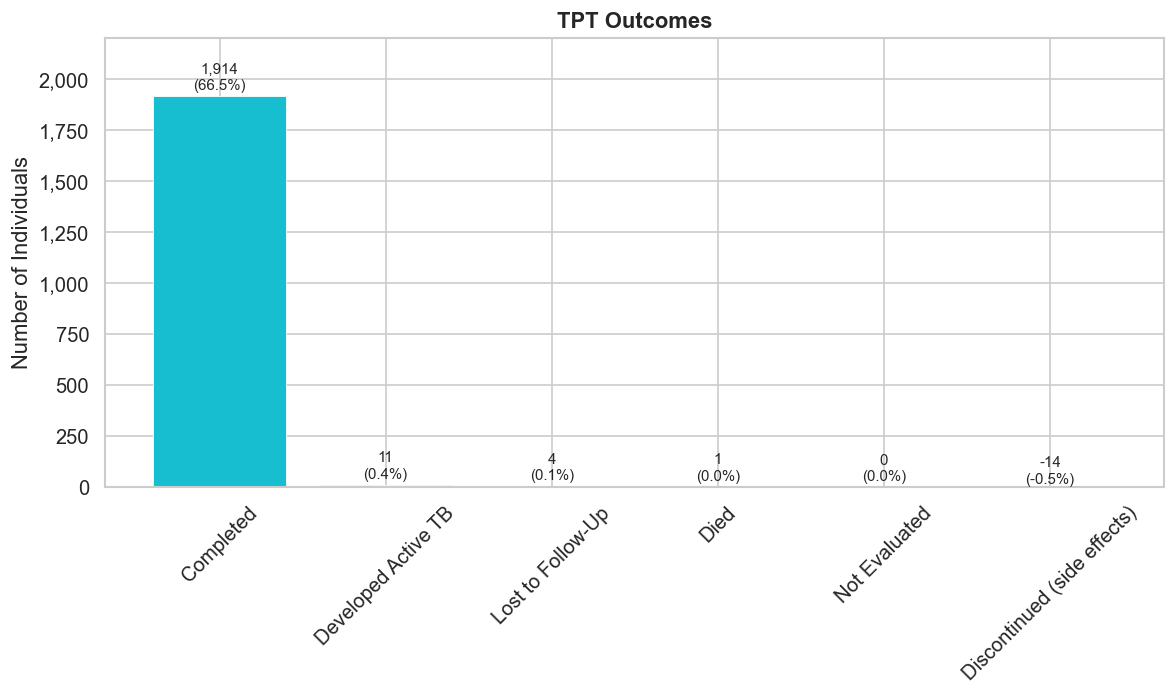

In [14]:
print("SECTION 7.2 — TPT COMPLETION OUTCOMES")


# Define colors
TEAL = "#17becf"

# 1. Total TPT initiated (already calculated in 7.1)
# We'll recalc to be safe
tpt_started = 0
for col in ['tpt_started_u2', 'tpt_started_2to5', 'tpt_started_5plus']:
    if col in df.columns:
        tpt_started += df[col].sum()
    else:
        print(f" Column '{col}' not found – skipping.")
print(f"Total TPT initiated: {tpt_started:,}")

# 2. Outcome categories and their columns
outcome_dict = {
    'Completed': ['tpt_completed_u5', 'tpt_completed_5plus'],
    'Lost to Follow-Up': ['tpt_ltfu_u5', 'tpt_ltfu_5plus'],
    'Died': ['tpt_died_u5', 'tpt_died_5plus'],
    'Developed Active TB': ['tpt_active_tb_u5', 'tpt_active_tb_5plus'],
    'Discontinued (side effects)': ['tpt_se_u5', 'tpt_se_5plus'],
    'Not Evaluated': ['tpt_not_eval_u5', 'tpt_not_eval_5plus']
}

outcome_counts = {}
for outcome, cols in outcome_dict.items():
    total = 0
    for col in cols:
        if col in df.columns:
            total += df[col].sum()
        else:
            print(f" Column '{col}' not found – skipping.")
    outcome_counts[outcome] = total

# 3. Create a summary DataFrame
outcome_df = pd.DataFrame(list(outcome_counts.items()), columns=['Outcome', 'Cases'])
outcome_df = outcome_df.sort_values('Cases', ascending=False).reset_index(drop=True)
outcome_df['% of Initiated'] = (outcome_df['Cases'] / tpt_started * 100).round(1)

print("\n TPT Outcomes (among initiated):")
display(outcome_df)

# 4. Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(outcome_df['Outcome'], outcome_df['Cases'],
              color=TEAL, edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, outcome_df['% of Initiated']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + outcome_df['Cases'].max()*0.01,
            f"{int(bar.get_height()):,}\n({pct}%)",
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, outcome_df['Cases'].max() * 1.15)
ax.set_title('TPT Outcomes', fontweight='bold')
ax.set_ylabel('Number of Individuals')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig_7_2_tpt_outcomes.png', bbox_inches='tight', dpi=150)
plt.show()

# ════════════════════════════════════════════════════════════════════════════════
# CELL 7.3 — TPT Cascade by Age Group (<5 and ≥5 years)
# ════════════════════════════════════════════════════════════════════════════════


SECTION 7.3 — TPT CASCADE BY AGE GROUP

▶ TPT Cascade by Age Group:


,Age Group,Eligible,Started,Completed,Completion Rate (%)
0,<5 years,"1,394","1,301",800,61.5
1,≥5 years,"22,922","1,577","1,114",70.6


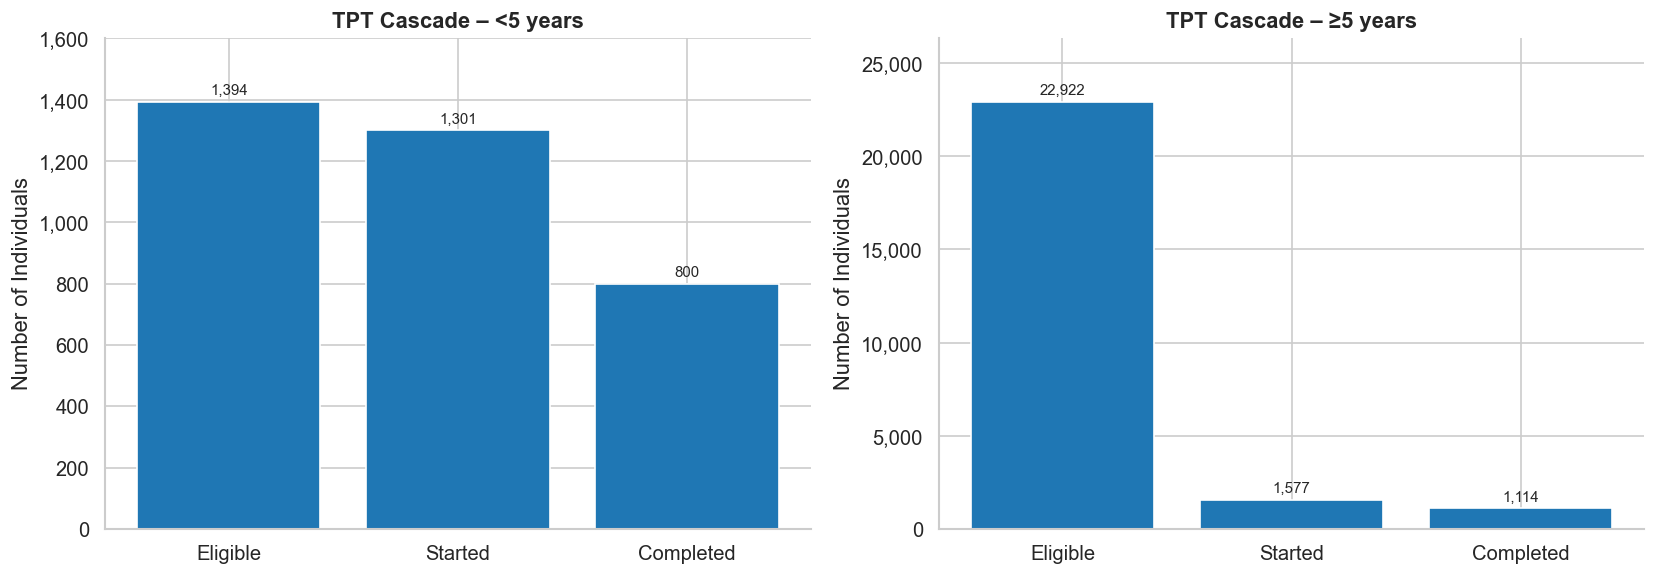

In [11]:

print("\n" + "="*70)
print("SECTION 7.3 — TPT CASCADE BY AGE GROUP")
print("="*70)

# Define colors (if not already defined)
BLUE = "#1f77b4"

cascade_rows = []

# Under 5 years
if all(col in df.columns for col in ['contacts_u5_living', 'tpt_started_u2', 'tpt_started_2to5', 'tpt_completed_u5']):
    eligible_u5 = df['contacts_u5_living'].sum()
    started_u5 = df['tpt_started_u2'].sum() + df['tpt_started_2to5'].sum()
    completed_u5 = df['tpt_completed_u5'].sum()
    completion_rate_u5 = (completed_u5 / started_u5 * 100).round(1) if started_u5 > 0 else 0

    cascade_rows.append({
        'Age Group': '<5 years',
        'Eligible': eligible_u5,
        'Started': started_u5,
        'Completed': completed_u5,
        'Completion Rate (%)': completion_rate_u5
    })
else:
    print("Missing columns for under‑5 TPT cascade.")

# 5 years and above
if all(col in df.columns for col in ['contacts_5plus_living', 'tpt_started_5plus', 'tpt_completed_5plus']):
    eligible_5p = df['contacts_5plus_living'].sum()
    started_5p = df['tpt_started_5plus'].sum()
    completed_5p = df['tpt_completed_5plus'].sum()
    completion_rate_5p = (completed_5p / started_5p * 100).round(1) if started_5p > 0 else 0

    cascade_rows.append({
        'Age Group': '≥5 years',
        'Eligible': eligible_5p,
        'Started': started_5p,
        'Completed': completed_5p,
        'Completion Rate (%)': completion_rate_5p
    })
else:
    print("Missing columns for ≥5 TPT cascade.")

if cascade_rows:
    cascade_df = pd.DataFrame(cascade_rows)
    # Display with formatted numbers
    display_df = cascade_df.copy()
    display_df['Eligible'] = display_df['Eligible'].apply(lambda x: f"{x:,.0f}")
    display_df['Started'] = display_df['Started'].apply(lambda x: f"{x:,.0f}")
    display_df['Completed'] = display_df['Completed'].apply(lambda x: f"{x:,.0f}")
    print("\n▶ TPT Cascade by Age Group:")
    display(display_df)

    # Plot cascade as bar chart for each age group
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, row in enumerate(cascade_df.itertuples()):
        steps = ['Eligible', 'Started', 'Completed']
        counts = [row.Eligible, row.Started, row.Completed]
        ax = axes[i]
        bars = ax.bar(steps, counts, color=BLUE, edgecolor='white')
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                    f"{count:,}", ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, max(counts) * 1.15)
        ax.set_title(f'TPT Cascade – {row._1}', fontweight='bold')  # row._1 is the Age Group column
        ax.set_ylabel('Number of Individuals')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig('fig_7_3_tpt_cascade.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("No data available for TPT cascade by age group.")